In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
titanic_dataset = sns.load_dataset("titanic")
print(titanic_dataset.head(10))
print(titanic_dataset.info(10))
print(titanic_dataset.describe())

   survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0         0       3    male  22.0      1      0   7.2500        S   Third   
1         1       1  female  38.0      1      0  71.2833        C   First   
2         1       3  female  26.0      0      0   7.9250        S   Third   
3         1       1  female  35.0      1      0  53.1000        S   First   
4         0       3    male  35.0      0      0   8.0500        S   Third   
5         0       3    male   NaN      0      0   8.4583        Q   Third   
6         0       1    male  54.0      0      0  51.8625        S   First   
7         0       3    male   2.0      3      1  21.0750        S   Third   
8         1       3  female  27.0      0      2  11.1333        S   Third   
9         1       2  female  14.0      1      0  30.0708        C  Second   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes

In [20]:
clean_age = titanic_dataset['age'].dropna()
clean_deck = titanic_dataset['deck'].dropna()


In [21]:
total_passengers = titanic_dataset['survived'].count()
survived_passengers = titanic_dataset['survived'].sum()
survival_rate = survived_passengers / total_passengers * 100
print(f"Total Passengers: {total_passengers}")
print(f"Survived Passengers: {survived_passengers}")
print(f"Survival Rate: {survival_rate:.2f}%")


Total Passengers: 891
Survived Passengers: 342
Survival Rate: 38.38%


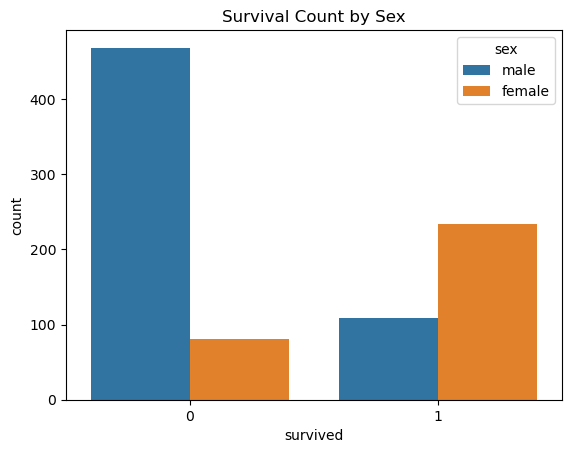

In [22]:
sns.countplot(titanic_dataset, x='survived', hue='sex')
plt.title('Survival Count by Sex')
plt.show()


In [23]:
titanic_dataset['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [24]:
titanic_dataset.groupby('sex')['survived'].mean()*100

sex
female    74.203822
male      18.890815
Name: survived, dtype: float64

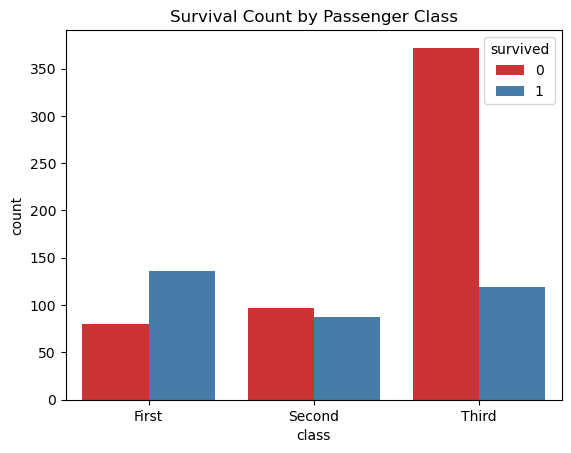

In [25]:
sns.countplot(titanic_dataset, x='class', hue='survived', palette='Set1')
plt.title('Survival Count by Passenger Class')
plt.show()


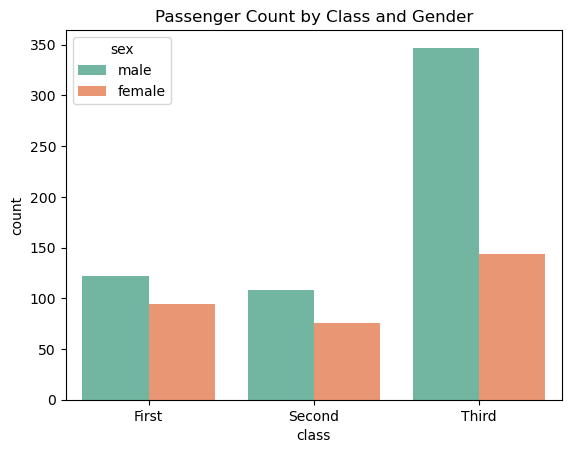

In [26]:
sns.countplot(titanic_dataset, x='class', hue='sex', palette='Set2')
plt.title('Passenger Count by Class and Gender')
plt.show()


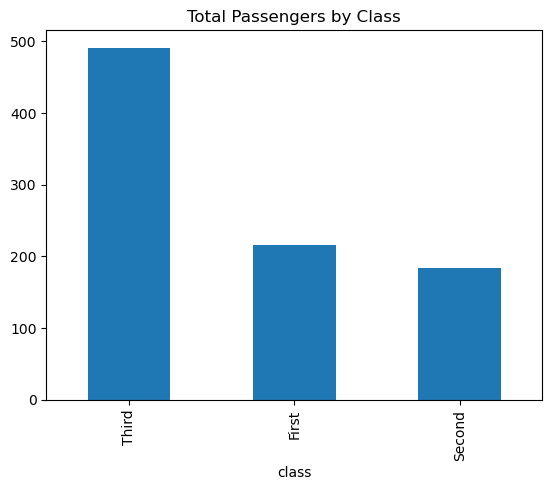

total passengers in each class class
Third     491
First     216
Second    184
Name: count, dtype: int64


class
First     62.962963
Second    47.282609
Third     24.236253
Name: survived, dtype: float64

In [27]:
titanic_dataset.value_counts('class').plot(kind='bar')
plt.title('Total Passengers by Class')
plt.show()

print('total passengers in each class',titanic_dataset['class'].value_counts())
titanic_dataset.groupby('class', observed=True)['survived'].mean()*100


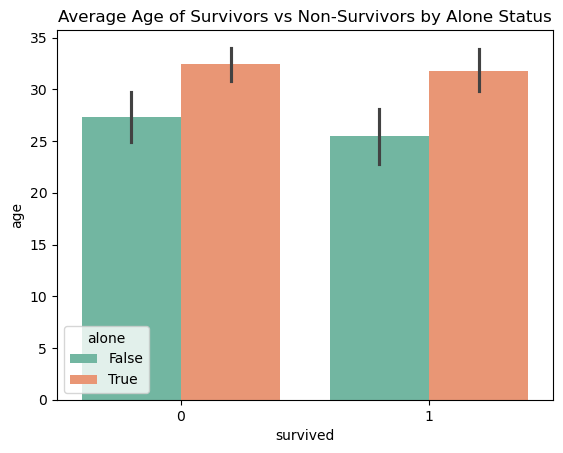

In [28]:
sns.barplot(titanic_dataset, x='survived', y='age', hue='alone', palette='Set2')
plt.title('Average Age of Survivors vs Non-Survivors by Alone Status')
plt.show()


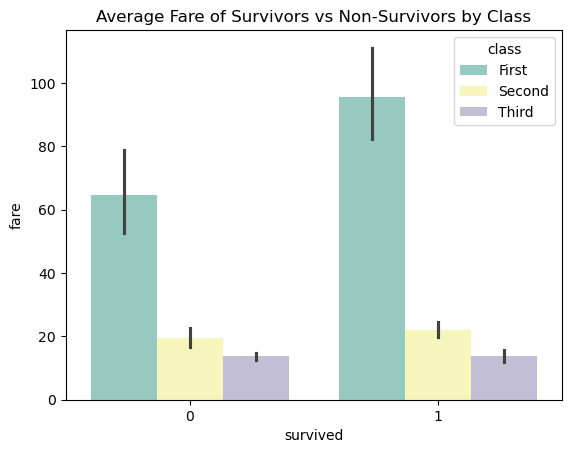

In [29]:
sns.barplot(titanic_dataset, x='survived', y='fare', hue='class', palette='Set3')
plt.title('Average Fare of Survivors vs Non-Survivors by Class')
plt.show()


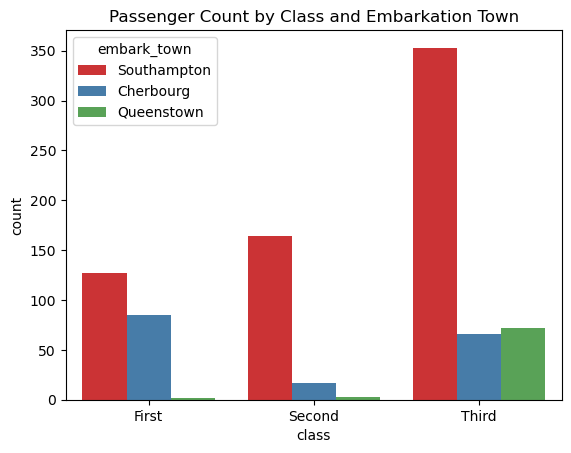

In [30]:
sns.countplot(titanic_dataset, x='class', hue='embark_town', palette='Set1')
plt.title('Passenger Count by Class and Embarkation Town')
plt.show()


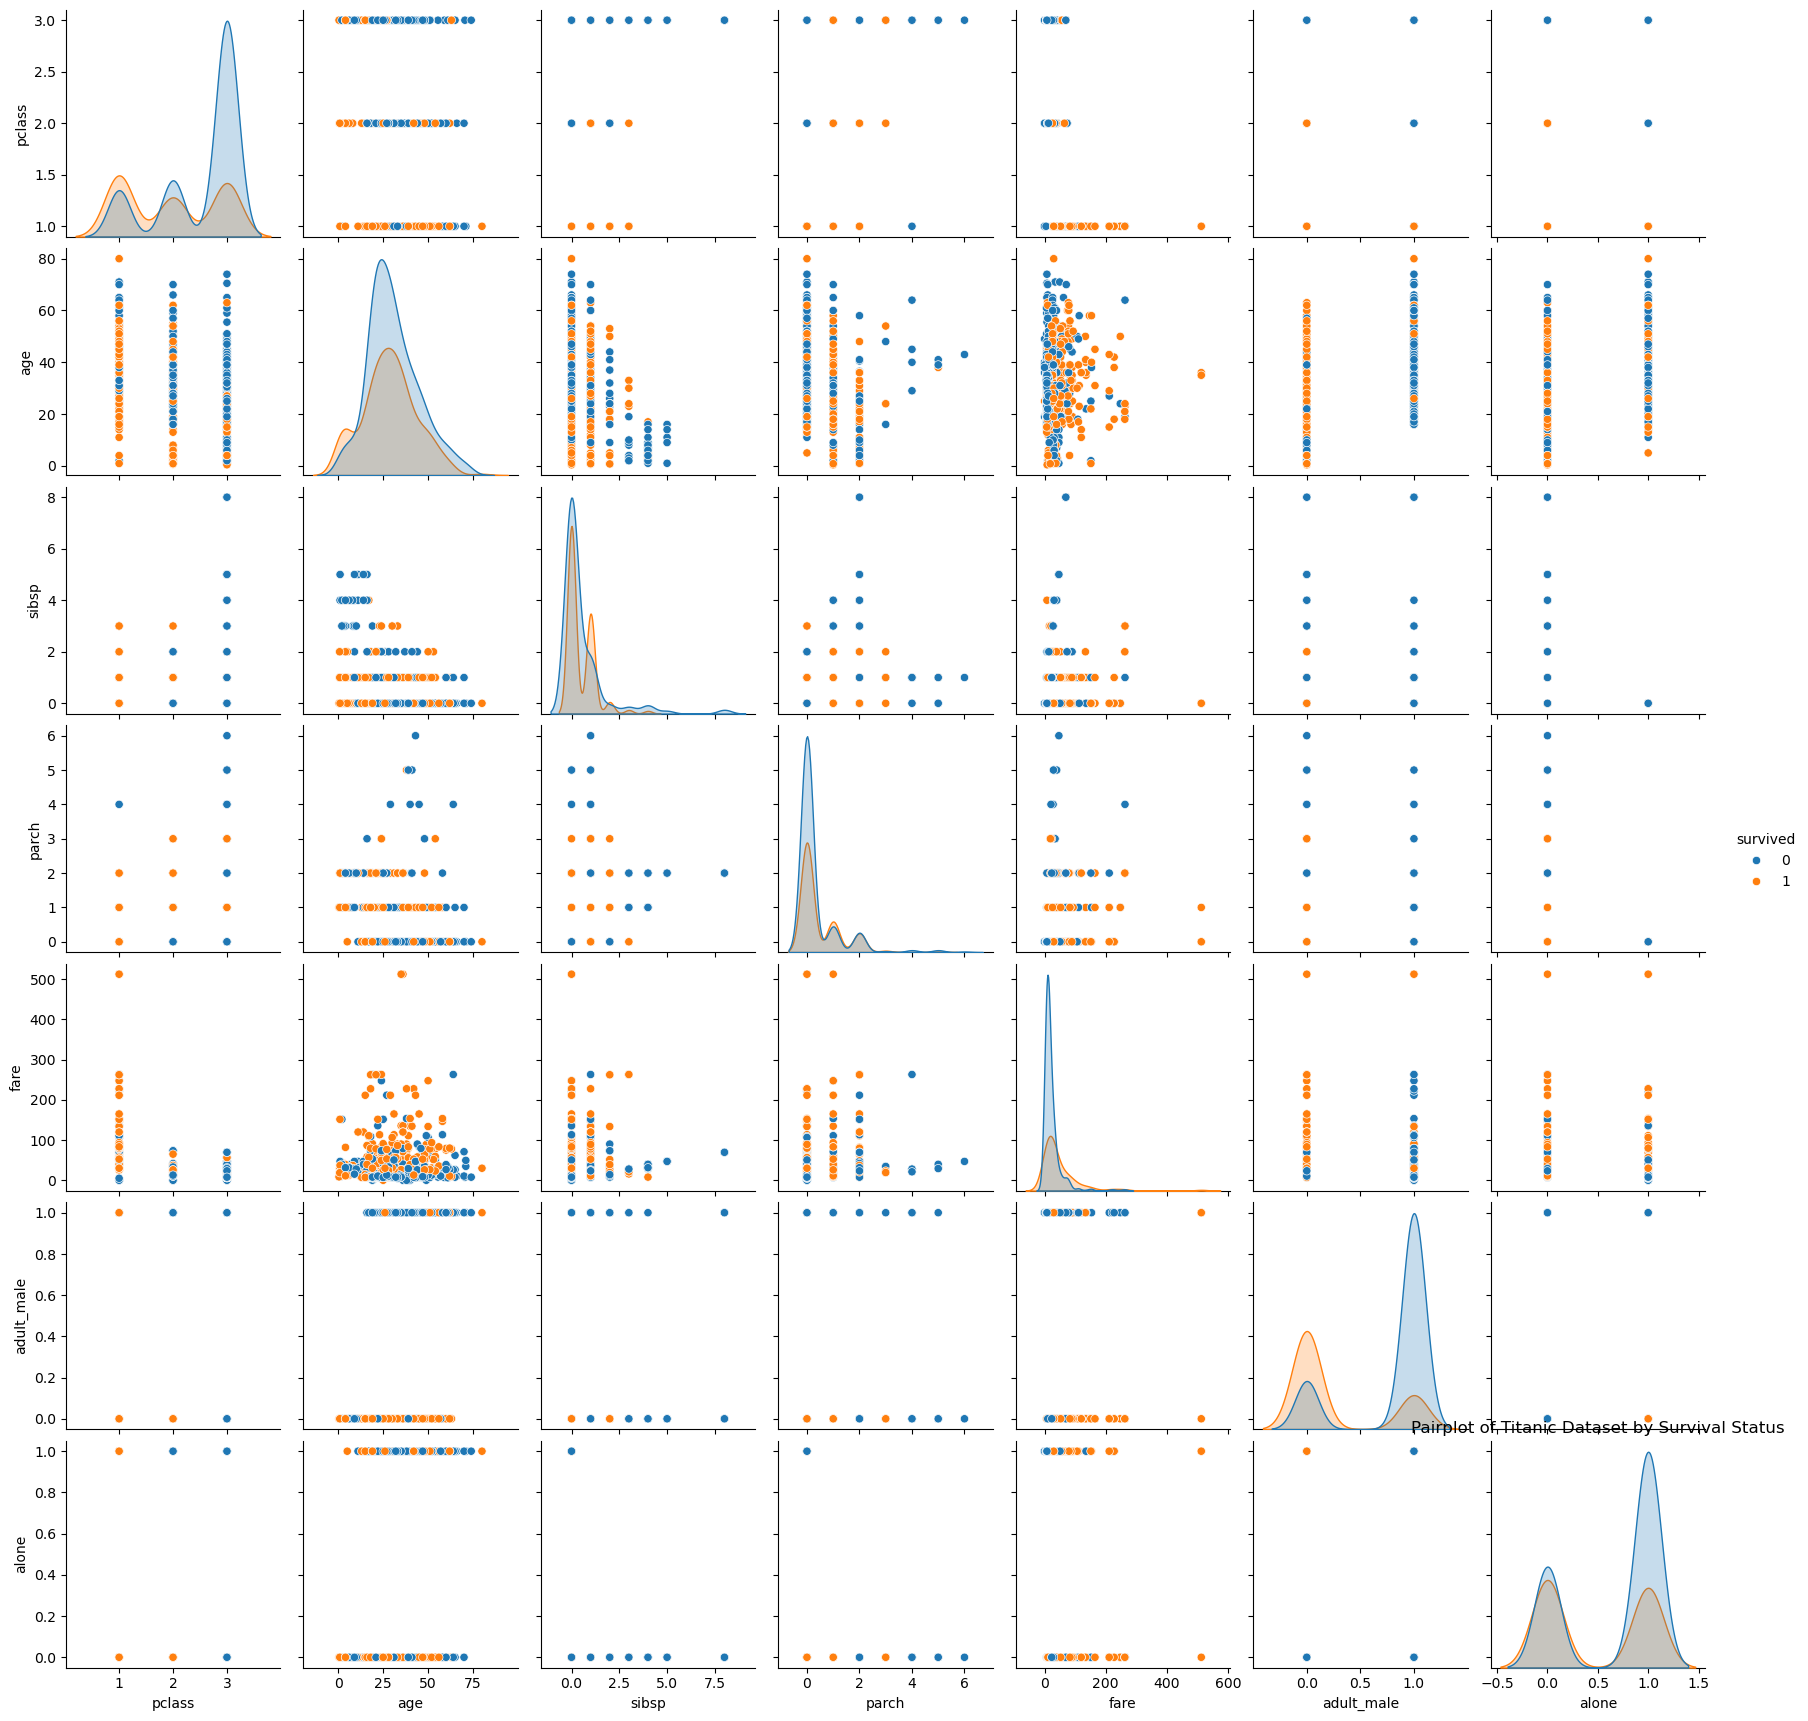

In [31]:
sns.pairplot(titanic_dataset, hue='survived', diag_kind='kde')
plt.title('Pairplot of Titanic Dataset by Survival Status')
plt.show()


Text(0.5, 0, 'Age')

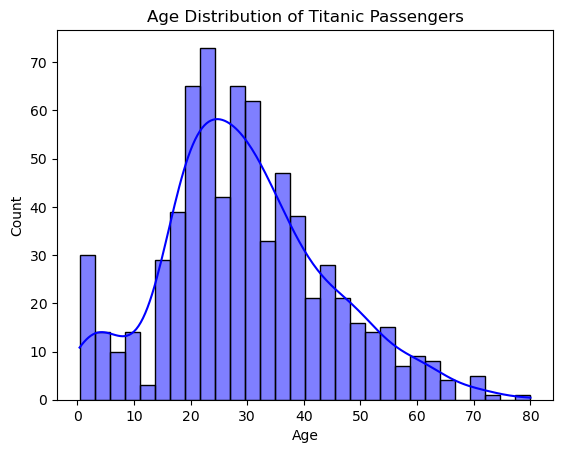

In [32]:
sns.histplot(clean_age, kde=True, bins=30, color='blue')
plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')

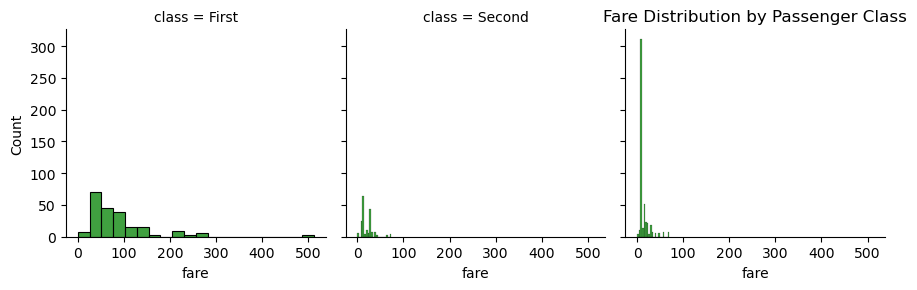

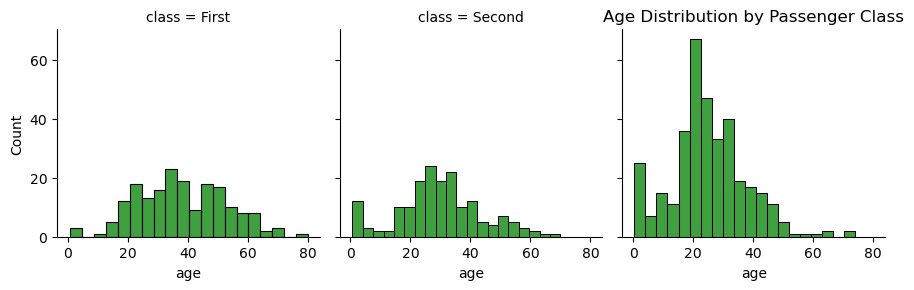

In [33]:
sns.FacetGrid(titanic_dataset, col='class').map_dataframe(sns.histplot, x='fare', bins=20, color='green').add_legend()
plt.title('Fare Distribution by Passenger Class')
plt.show()

sns.FacetGrid(titanic_dataset, col='class').map_dataframe(sns.histplot, x='age', bins=20, color='green').add_legend()
plt.title('Age Distribution by Passenger Class')
plt.show()


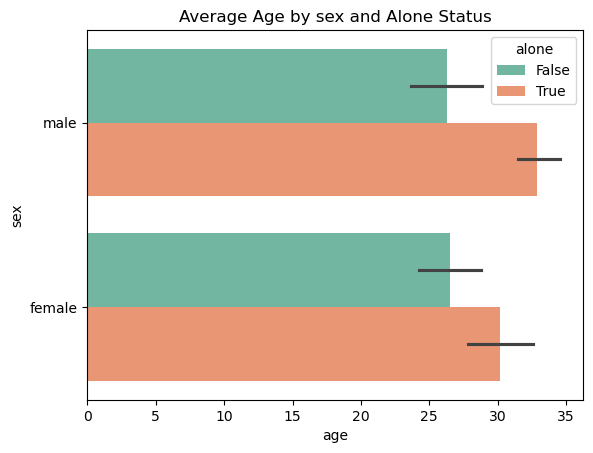

In [34]:
sns.barplot(titanic_dataset, x='age', y='sex', hue='alone', palette='Set2')
plt.title('Average Age by sex and Alone Status')
plt.show()


OBSERVATIONS:
1. The survival rate of male is considerably lower than that of female.
2. The passengers of female is 54% of that from male.
3. The female had a high percentage of survival.
4. The 3rd class has higher percentage of male than female.
5. 3rd class has the highest number of passengers.
6. Higher percentage of alone passengers than with company.
7. 1st class has the highest survival rate.
8. Most passenger boarded from Southampton.
9. Distribution of age is concentrated between 20 and 30.
10. Concentration of fare in 3rd class is skewed, concentrated near 0 with a few paying higher.
11. 3rd class distribution in age is concentrated near 20.

Visual References:
-sns.countplot(x='sex', hue='survived', data=titanic)
-sns.histplot(data=titanic, x='fare', hue='class', bins=20)
-sns.boxplot(x='class', y='age', data=titanic)

INSIGHTS:
1. The percentage of men and women had a huge disparity likely because there are workers who is mostly male in the 3rd class that also has the highest number of passengers.
2. Upon investigation, the ship followed the 'women and children first safety protocol' which is why females had a higher percentage of survival rate.
3. Travelers who is age of 30 to 40 has a higher percentage of 'alone' status reasoning that young is often accompanied by adults.
4. 1st class has the most survival rates because they are near the rescue boats mentioned meanwhile 3rd class has the most casualty because the initial impact of the iceberg was from the third class and with little to no access in rescue boats, they didn't survive.
5. Southampton's dominance aligns with its role as Titanic's departure port, where most emigrants boarded. Factoring that, most of the victims has boarded from Southampton.
6. Third class being Young workforce 

Visual References:
-sns.barplot(x='class', y='survived', hue='sex', data=titanic)
-sns.histplot(x='age', hue='alone', data=titanic, bins=20)
-sns.countplot(x='embark_town', hue='class', data=titanic)

SUMMARY:
Most of victims boarded from Southampton and would be considered a "young workforce" departing to America.
1st class survived because of easier access in lifeboats
This analysis demonstrates how data visualization and simple statistics can uncover real-world social dynamics hidden within historical datasets.
By combining Pandas, Seaborn, and NumPy, I learned to:
Interpret categorical and numerical data relationships.
Understand how patterns in age, fare, and class translate into real human stories.
Use data storytelling to make findings more meaningful than numbers alone.